# Import 

In [15]:
import kagglehub
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

# Export data from kaggle

In [16]:
# Get Notebook Folder
path = Path.cwd()

# Download latest version from kaggle
kagglepath = Path(
    kagglehub.dataset_download('janiobachmann/bank-marketing-dataset')
)

# Destination Folder
destination_folder = path
destination_folder.mkdir(parents=True, exist_ok=True)

# copy file
for file in kagglepath.iterdir() :
    if file.is_file() :
        shutil.copy2(file, destination_folder / file.name)

print(f'data saved in : \n {path}')

data saved in : 
 e:\Hacktiv8\Project\Banking Marketing Dataset


# Business Background

In the banking industry, third-party funds—such as savings, current accounts, and time deposits—serve as the primary funding sources to support operational activities and credit distribution. Consequently, increasing the number of customers willing to open time deposits remains a critical target for the bank's marketing division.

Every marketing initiative incurs costs, including communication expenses, sales workforce overhead, operational time, and customer relationship management. Since not all customers are interested in time deposit products, contacting the entire customer base without a strategic approach can lead to an inefficient allocation of resources.

By leveraging historical marketing campaign data, banks have the opportunity to evaluate the factors associated with campaign successes and failures. This analysis helps in understanding customer characteristics, the effectiveness of marketing strategies, and customer response patterns toward the offers presented.

# Business Context

Bank secara rutin menjalankan kampanye pemasaran melalui telepon untuk menawarkan produk term deposit kepada pelanggan yang sudah ada maupun calon pelanggan. Setiap panggilan yang dilakukan memerlukan sumber daya berupa tenaga pemasaran, waktu, serta biaya operasional.

Meskipun campaign telah dilakukan kepada ribuan pelanggan, hanya sebagian kecil yang akhirnya memutuskan untuk membuka deposito. Kondisi ini menunjukkan bahwa tidak semua pelanggan memiliki peluang yang sama untuk menerima penawaran tersebut.

Oleh karena itu, pihak manajemen membutuhkan pemahaman mengenai faktor-faktor yang berkaitan dengan keberhasilan subscription. Informasi tersebut diharapkan dapat membantu tim pemasaran dalam menentukan segmen pelanggan yang lebih potensial, mengevaluasi efektivitas campaign, serta mengalokasikan sumber daya pemasaran secara lebih efisien.

# Problem Identification

Banks routinely conduct telemarketing campaigns to offer term deposit products to customers. However, each marketing activity requires significant operational costs, labor, and time. On the other hand, not all contacted customers are willing to open a deposit.

Without knowing the characteristics of customers who are more likely to accept the offer and the factors influencing campaign success, the bank risks allocating marketing resources inefficiently. Therefore, an analysis of historical data is required to understand campaign success patterns so that subsequent marketing strategies can be more accurately targeted.

## SMART Method

### Specific

Identifying customer characteristics and campaign factors associated with customers' decisions to subscribe to term deposits

### Measurable

Identifying factors that have a significant relationship with campaign success and measuring the conversion rate across each customer segment

### Achievable

Formulating campaign strategy recommendations based on historical data analysis insights to help enhance campaign effectiveness

### Relevant

- Bank can understand the characteristics of potential customers who are likely to subscribe to term deposits

- Bank can evaluate campaign strategies effectively

- Bank can make data-driven, more effective decisions and improve resource efficiency

### Time - Bound

The analysis is conducted using historical data as the foundation for formulating campaign strategy recommendations that can be implemented in the subsequent campaign period.

# Project Scope

The analysis in this project focuses on evaluating the effectiveness of deposit marketing campaigns based on available historical data. The discussion encompasses the analysis of customer characteristics, financial conditions, and campaign factors associated with customers' decisions to subscribe to deposit products.

# Data

## Data Source

The data source used is the 'Bank Marketing Dataset' from Kaggle, which contains historical data on the outcomes of deposit campaigns conducted by a bank. The campaigns were carried out via telephone. Each row in the dataset represents a single campaign interaction with a customer.

## Import & Understanding Data

In [17]:
df = pd.read_csv('bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [18]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [19]:
print(f'rows : {df.shape[0]}')
print(f'columns : {df.shape[1]}')

rows : 11162
columns : 17


In [20]:
print('Dataset structure : \n')
df.info()
print('\n\n Descriptive Statistics :')
df.describe().T

Dataset structure : 

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


 Descriptive Statistics :


,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [21]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

## Data Summary

Based on the data understanding conducted on the dataset, there are 17 variables or columns and 11,162 rows of data. There are no missing values or duplicate values.

# Business Question / Analytical Question

1. What is the overall distribution of the deposit campaigns conducted by the bank?
2. What are the characteristics of customers who exhibit a high propensity to subscribe to term deposits?
3. Is there a relationship between a customer's financial profile and their interest in subscribing to term deposits?
4. How well did the marketing campaigns perform in driving term deposit subscriptions?

# EDA & Business Insight

## Question 1

What is the overall distribution of the deposit campaigns conducted by the bank?

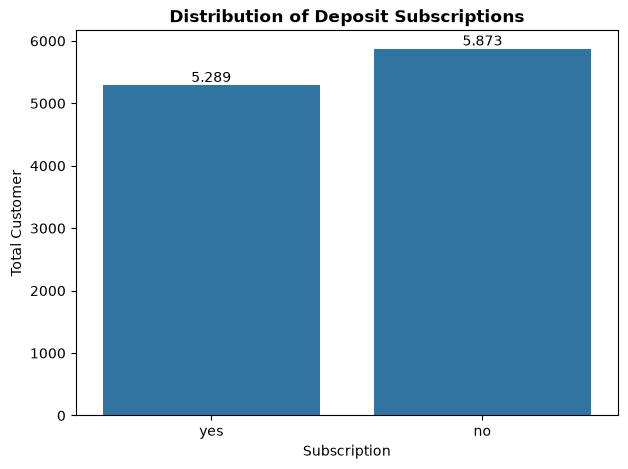

In [24]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, 
                   x='deposit', 
                   legend=False)

ax.set(
    title='Distribution of Deposit Subscriptions', 
    xlabel='Subscription', 
    ylabel='Total Customer')

ax.title.set_weight('bold')

for container in ax.containers :
    value_label = [f'{value:,.0f}'.replace(',', '.') for value in container.datavalues] 
    ax.bar_label(container, labels=value_label) 

plt.show()

Insight :

Based on the graph, out of the 11,162 customers contacted, only 5,289 decided to subscribe to a deposit, while 5,873 did not. This indicates that the success rate of the campaign remains relatively low, as the majority of the customers have not yet been successfully converted to subscribe to deposits.

## Question 2

What are the characteristics of customers who exhibit a high propensity to subscribe to term deposits?

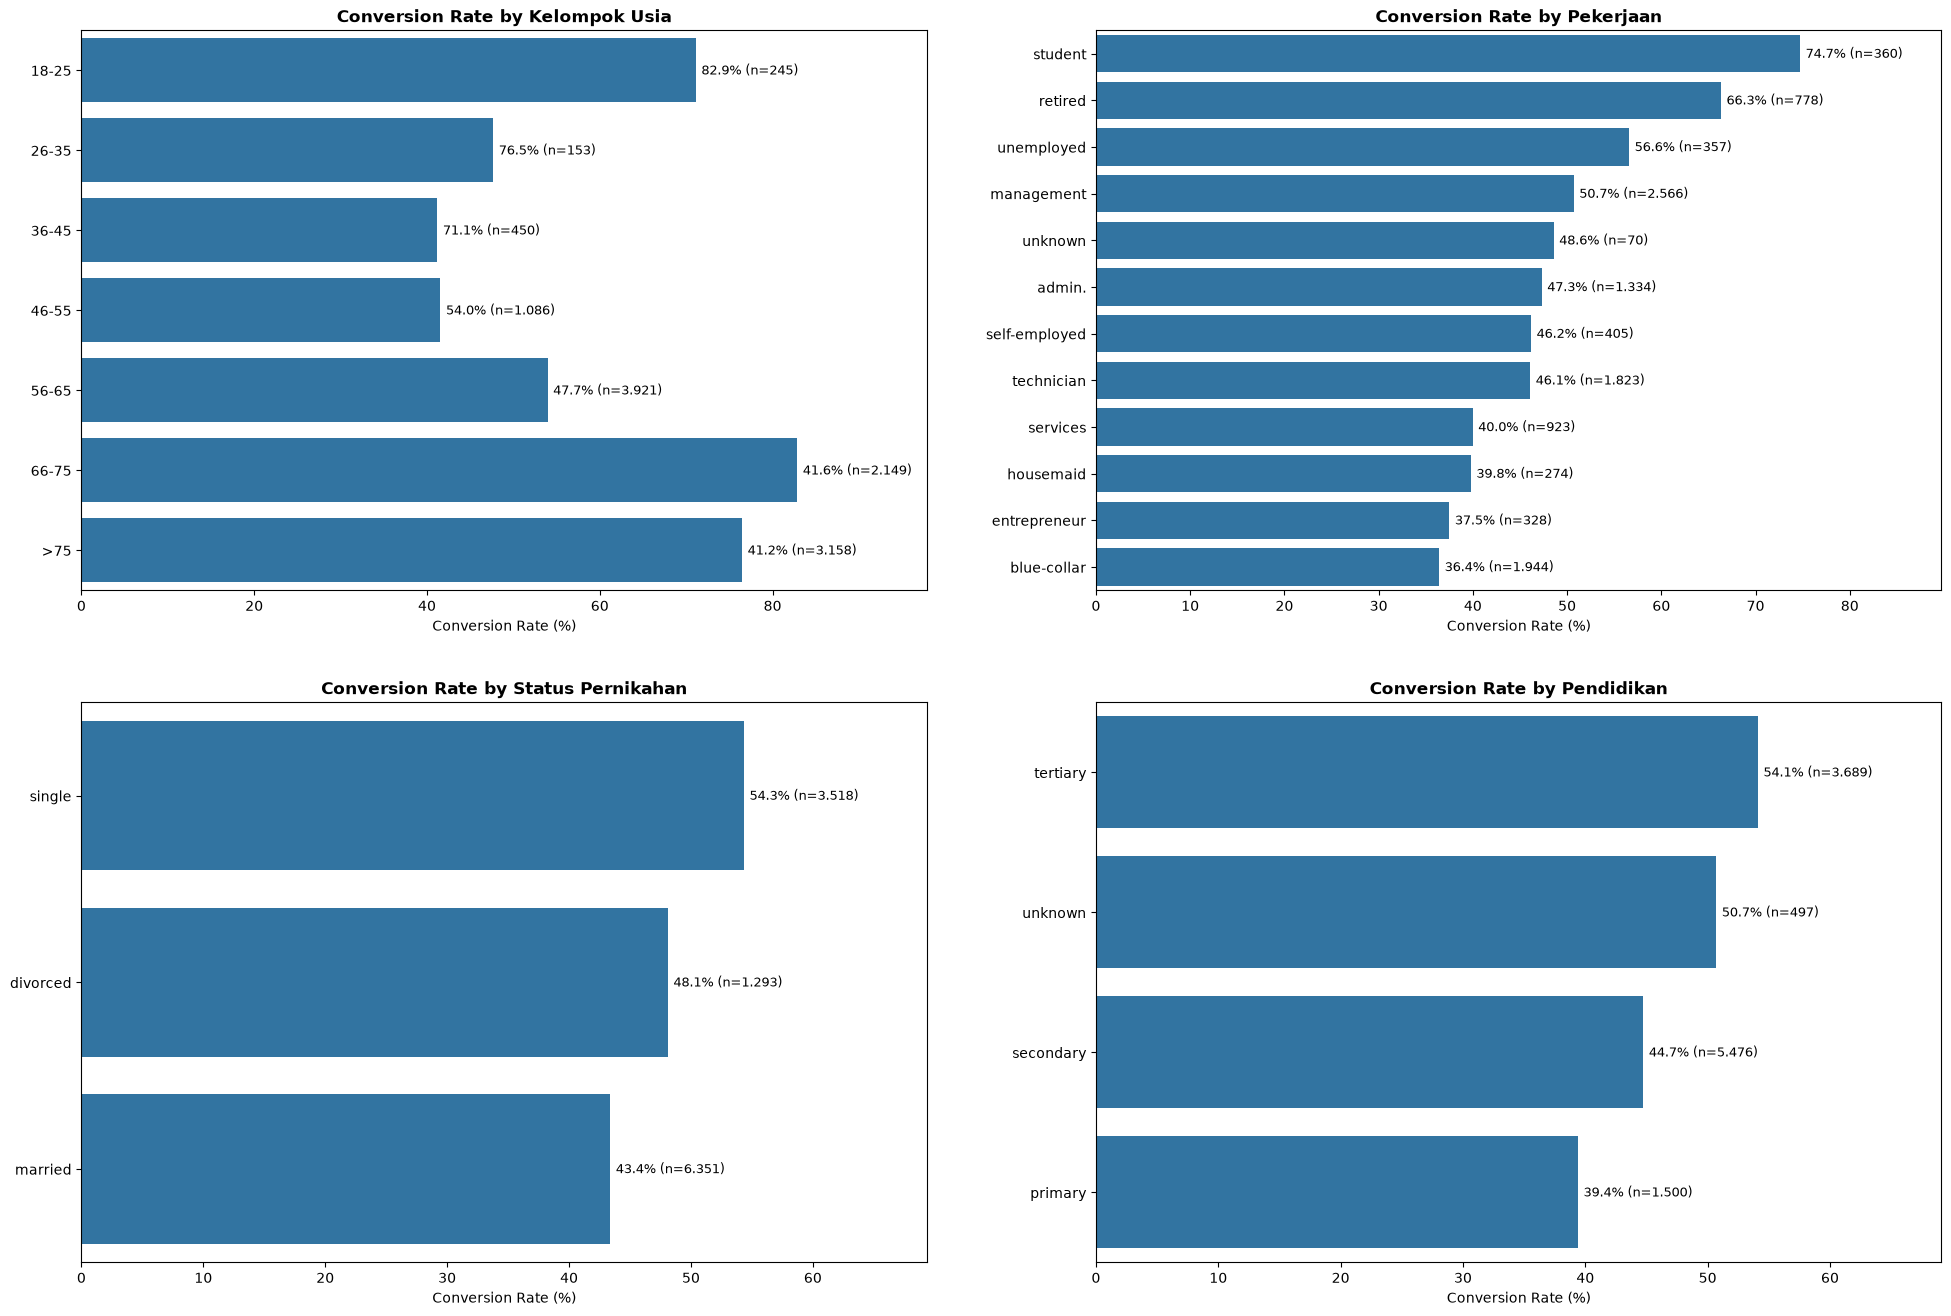

In [25]:
# Kategori usia
ages = [18, 25, 35, 45, 55, 65, 75, 100]
age_labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '66-75',
    '>75'
]

df_plot = df.copy()

df_plot['age_category'] = pd.cut(
    df_plot['age'],
    bins=ages,
    labels=age_labels,
    include_lowest=True
)

# Hitung Conversion Rate
def conversion_rate(data, column):

    result = (
        data.groupby(column, observed=True)
        .agg(
            total_customer=('deposit', 'count'),
            conversion_rate=('deposit', lambda x: (x == 'yes').mean() * 100)
        )
        .reset_index()
        .sort_values('conversion_rate', ascending=False)
    )

    return result


# Visualisasi
fig, axes = plt.subplots(
    2, 2,
    figsize=(24, 16)
)

columns = [
    'age_category',
    'job',
    'marital',
    'education'
]

titles = [
    'Kelompok Usia',
    'Pekerjaan',
    'Status Pernikahan',
    'Pendidikan'
]

for ax, column, title in zip(
    axes.flatten(),
    columns,
    titles
):

    plot_data = conversion_rate(df_plot, column)

    sns.barplot(
        data=plot_data,
        x='conversion_rate',
        y=column,
        legend=False,
        ax=ax
    )

    ax.set(
        title=f'Conversion Rate by {title}',
        xlabel='Conversion Rate (%)',
        ylabel=''
    )

    ax.title.set_weight('bold')

    ax.set_xlim(0, plot_data['conversion_rate'].max() + 15)

    labels = [
        f'{rate:.1f}% (n={total:,})'.replace(',', '.')
        for rate, total in zip(
            plot_data['conversion_rate'],
            plot_data['total_customer']
        )
    ]

    ax.bar_label(
        ax.containers[0],
        labels=labels,
        padding=4,
        fontsize=9
    )

plt.show()

Insight :

The graph above illustrates the characteristics of the customer segments with the highest deposit subscription conversion rates.
- By Age Category: The majority of conversions are among individuals aged 18–25, achieving a conversion rate of 82.9%.
- By Job Category: In terms of conversion rate, students represent the highest-performing segment at 74.7%.
- By Marital Status: Single individuals exhibit a higher propensity to convert, with a conversion rate of 54.3%.
- By Education Category: Customers with a tertiary education level achieve the highest conversion rate at 54.1%.

## Question 3

Is there a relationship between a customer's financial profile and their interest in subscribing to term deposits?

In [26]:
df['balance'].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

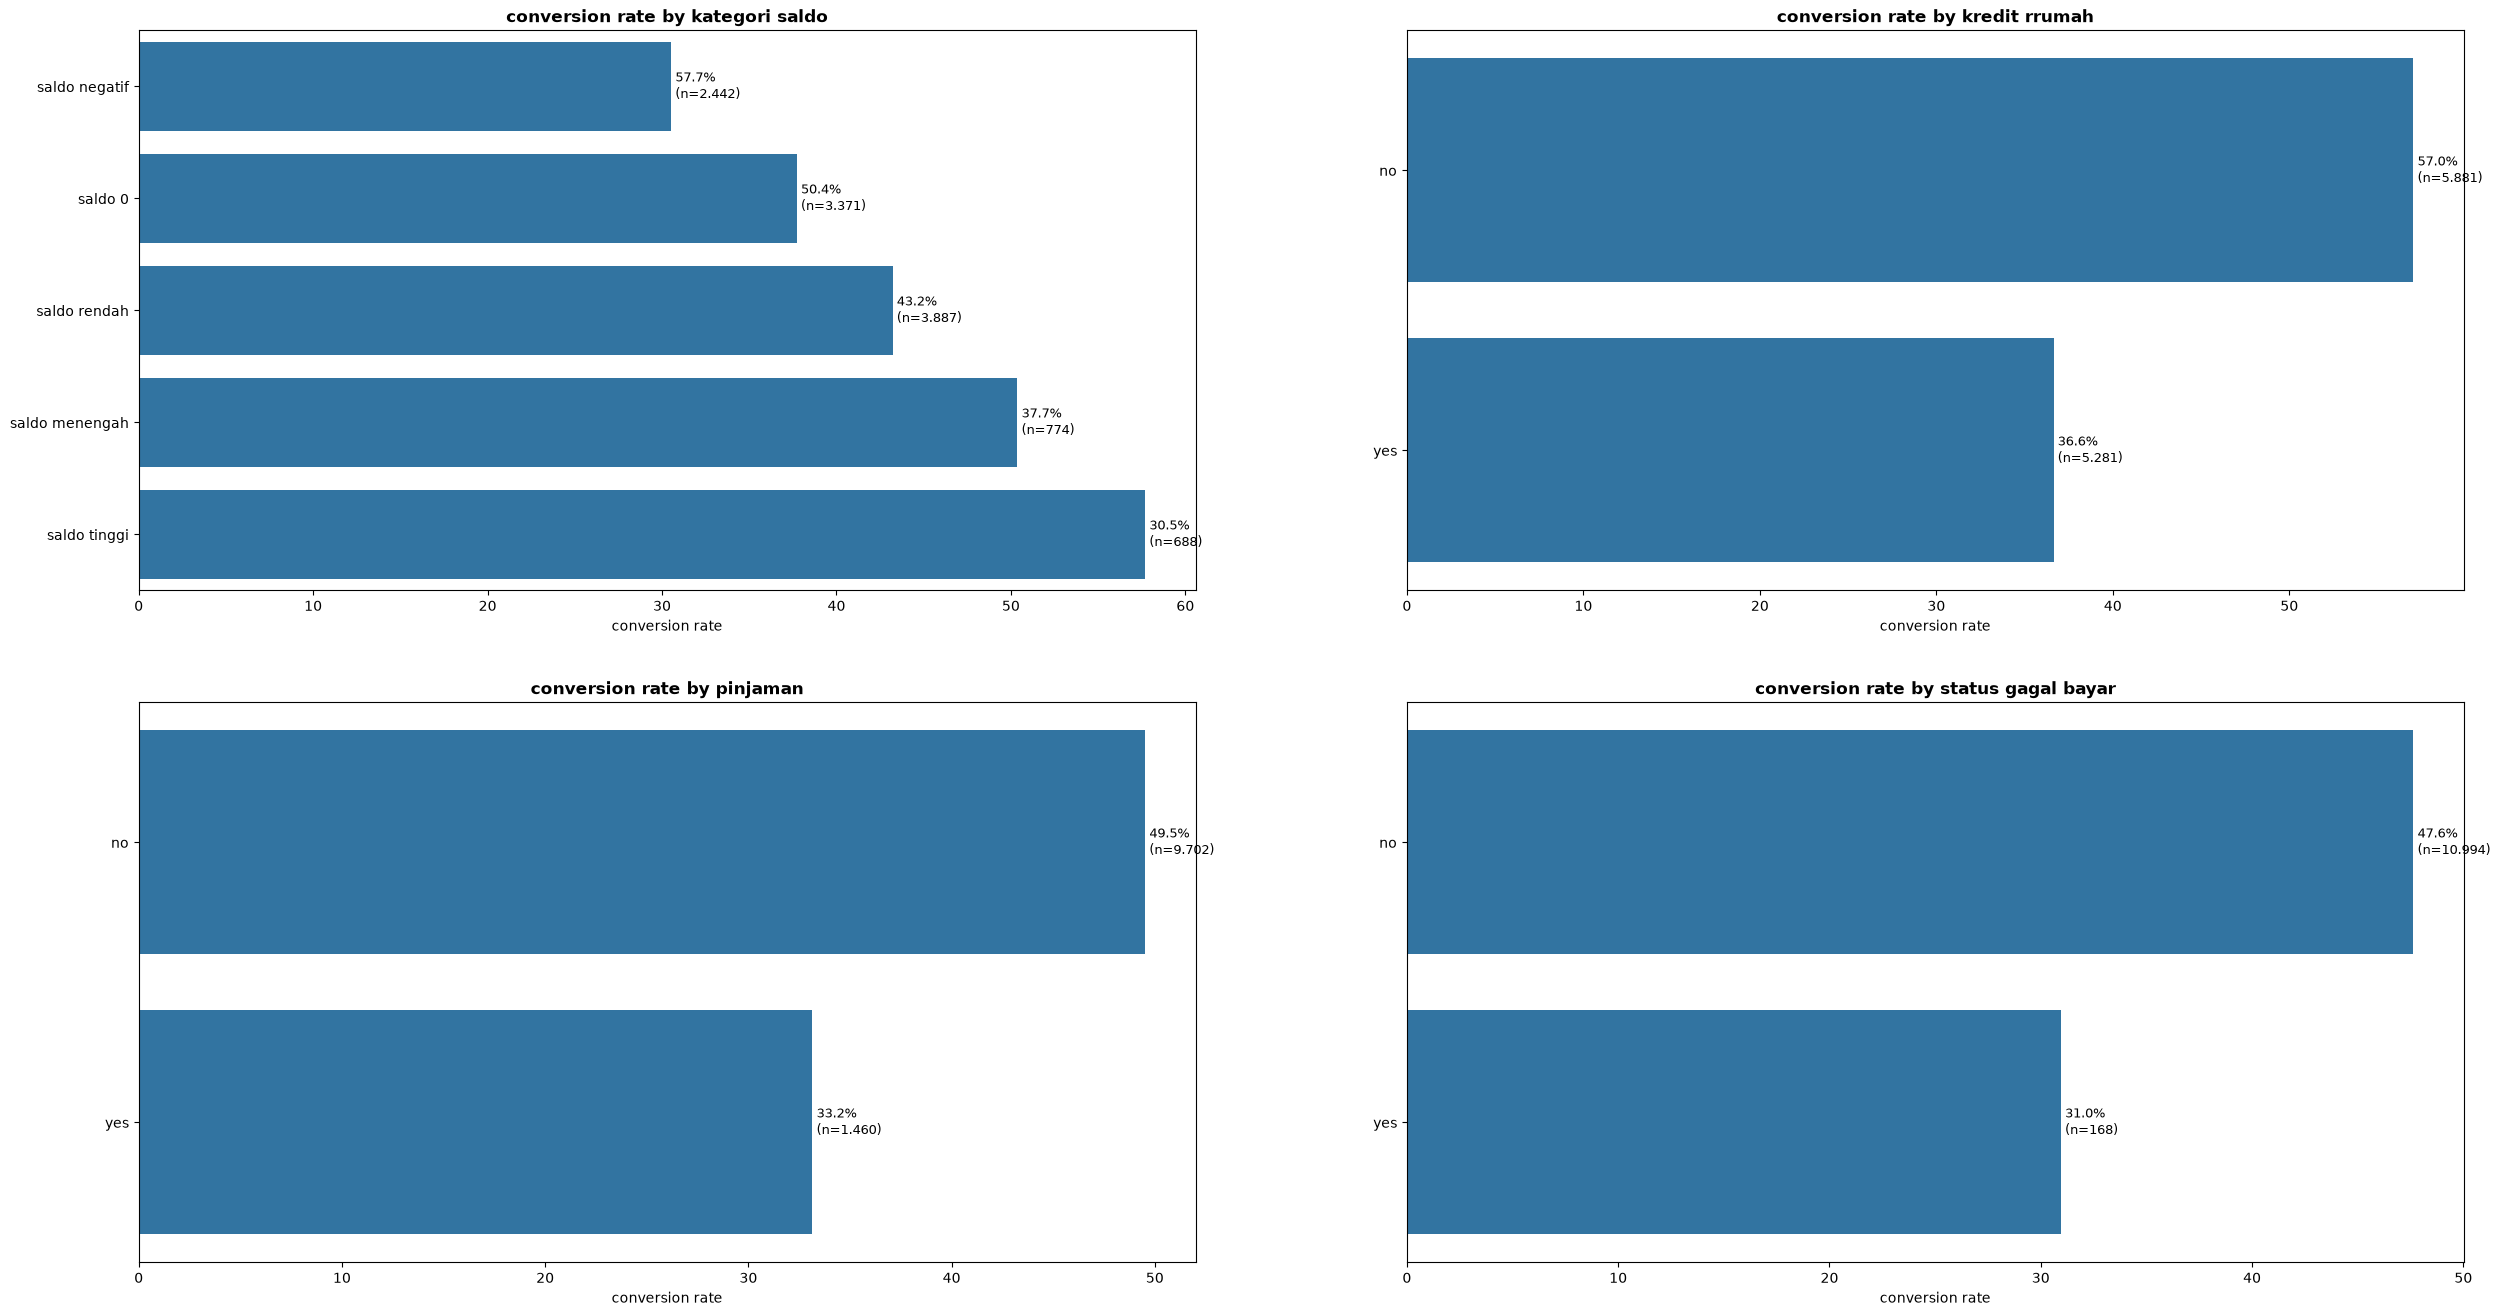

In [27]:
df_plot = df.copy()

bals = [
    df_plot['balance'] < 0,
    df_plot['balance'] == 0,
    (df_plot['balance'] >= 1) & (df_plot['balance'] <= 500),
    (df_plot['balance'] >= 501) & (df_plot['balance'] <= 2000),
    df_plot['balance'] > 2000
]

bal_category = [
    'saldo negatif', # Negative Balance
    'saldo 0', # Zero Balance
    'saldo rendah', # Low Balance
    'saldo menengah', # Medium Balance
    'saldo tinggi' # High Balance
]

df_plot['balance_category'] = np.select(
    bals,
    bal_category,
    default = 'Unknown'
)

df_plot['balance_category'] = pd.Categorical(
    df_plot['balance_category'],
    categories = bal_category,
    ordered = True
)

# Visualisasi
fig, axes = plt.subplots(
    2,2,
    figsize = (30,16)
)

columns = [
    'balance_category',
    'housing',
    'loan',
    'default'
]

titles = [
    'kategori saldo',
    'kredit rrumah',
    'pinjaman',
    'status gagal bayar'
]

for ax, column, title in zip(
    axes.flatten(),
    columns,
    titles
) :
    plot_data = conversion_rate(df_plot, column)

    sns.barplot(
        data = plot_data,
        x = 'conversion_rate',
        y = column,
        ax = ax,
        legend = False
    )

    ax.set(
        title = f'conversion rate by {title}',
        xlabel = 'conversion rate',
        ylabel = ''
    )

    ax.title.set_weight('bold')

    labels = [
        f"{rate:.1f}%\n(n={total:,})".replace(",", ".")
        for rate, total in zip(
            plot_data["conversion_rate"],
            plot_data["total_customer"]
        )
    ]

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

plt.show()

Insight :
- By Balance Category: Customers with a high balance represent the highest conversion target, with a conversion rate of 57.7%.
- By Housing Loan Category: Customers without a housing loan exhibit a higher conversion rate, reaching 57.0%.
- By Loan Category: Customers without personal loans achieve a higher conversion rate at 49.5%.
- By Credit Default Category: Customers with no history of credit default are successfully converted at a higher rate of 47.6%.


## Question 4

How well did the marketing campaigns perform in driving term deposit subscriptions?

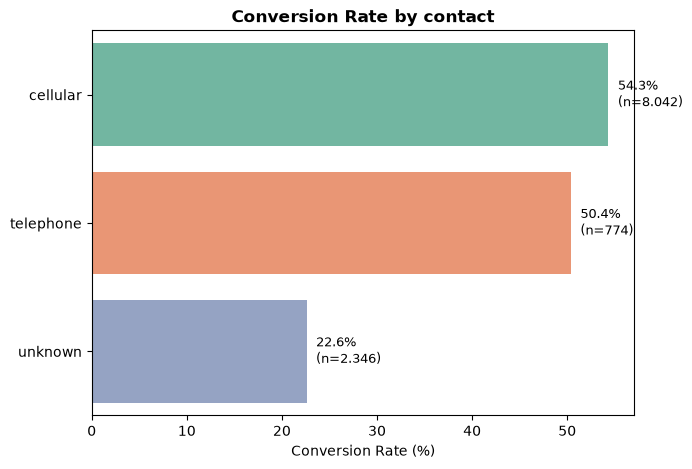

In [28]:
contact_plot = (
    df.groupby("contact", observed=True)
    .agg(
        total_customer=("deposit", "count"),
        conversion_rate=("deposit", lambda x: (x == "yes").mean() * 100)
    )
    .reset_index()
    .sort_values("conversion_rate", ascending=False)
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=contact_plot,
    x="conversion_rate",
    y="contact",
    palette="Set2",
    hue="contact",
    legend=False
)

ax.set(
    title="Conversion Rate by contact",
    xlabel="Conversion Rate (%)",
    ylabel=""
)

ax.title.set_weight("bold")

# Value Label
for i, row in contact_plot.iterrows():

    ax.text(
        row["conversion_rate"] + 1,
        i,
        f'{row["conversion_rate"]:.1f}%\n(n={row["total_customer"]:,})'.replace(",", "."),
        va="center",
        fontsize=9
    )

plt.show()

Insight :

The visualization shows that cellular communication media yields a conversion rate of 54.3%, slightly higher than telephone, which has a conversion rate of 50.4%.

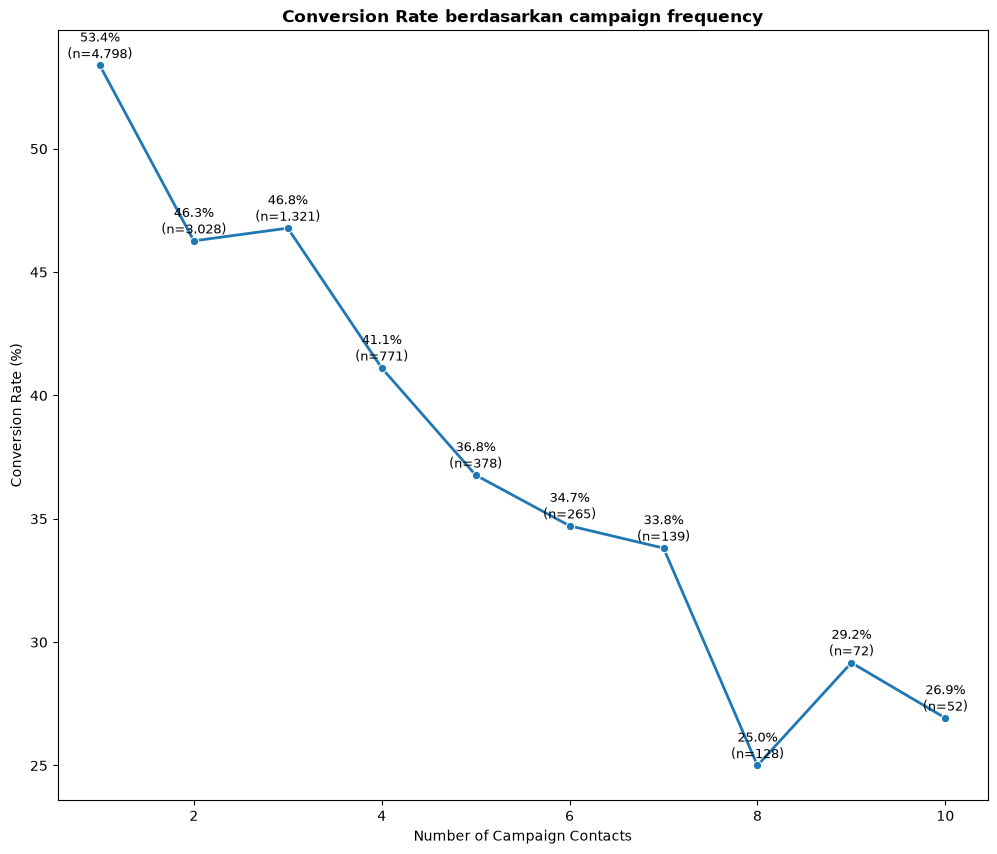

In [29]:
campaign_plot = (
    df.groupby("campaign", observed=True)
    .agg(
        total_customer=("deposit", "count"),
        conversion_rate=("deposit", lambda x: (x == "yes").mean() * 100)
    )
    .reset_index()
)

campaign_plot = campaign_plot[
    campaign_plot["campaign"] <= 10
]

plt.figure(figsize=(12,10))

ax = sns.lineplot(
    data=campaign_plot,
    x="campaign",
    y="conversion_rate",
    marker="o",
    linewidth=2
)

ax.set(
    title="Conversion Rate berdasarkan campaign frequency",
    xlabel="Number of Campaign Contacts",
    ylabel="Conversion Rate (%)"
)

ax.title.set_weight("bold")

for _, row in campaign_plot.iterrows():

    ax.text(
        row["campaign"],
        row["conversion_rate"] + 0.3,
        f"{row['conversion_rate']:.1f}%\n(n={int(row['total_customer']):,})".replace(",", "."),
        ha="center",
        fontsize=9
    )

plt.show()

Insight :

The highest conversion rate occurs during the first customer contact at 53.4%. After contacts exceed 4 times, the conversion rate tends to decline. This indicates that campaign success is heavily concentrated within the first 1 to 3 contacts, whereas repeated follow-ups tend to be associated with lower campaign success rates.

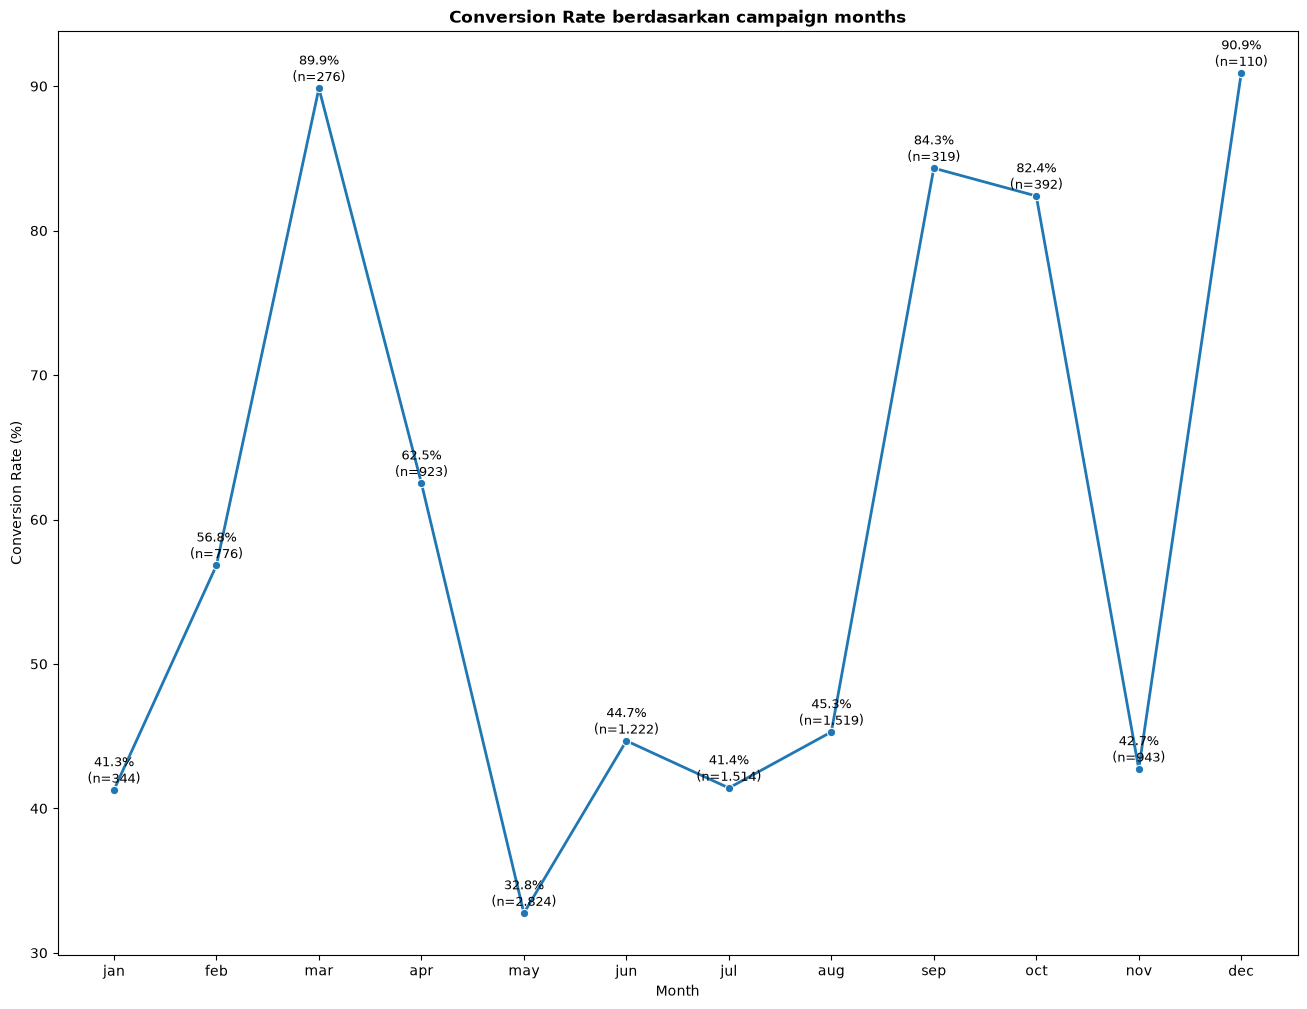

In [30]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

df_plot = df.copy()

df_plot['month'] = pd.Categorical(
    df_plot['month'],
    categories=month_order,
    ordered=True
)

month_plot = (
    df_plot.groupby('month', observed=True)
    .agg(
        total_customer=('deposit', 'count'),
        conversion_rate=('deposit',
                         lambda x: (x == 'yes').mean() * 100)
    )
    .reset_index()
)

plt.figure(figsize=(16,12))

ax = sns.lineplot(
    data=month_plot,
    x='month',
    y='conversion_rate',
    marker='o',
    linewidth=2
)

ax.set(
    title='Conversion Rate berdasarkan campaign months',
    xlabel='Month',
    ylabel='Conversion Rate (%)'
)

ax.title.set_weight('bold')

for _, row in month_plot.iterrows():

    ax.text(
        row['month'],
        row['conversion_rate'] + 0.5,
        f"{row['conversion_rate']:.1f}%\n(n={row['total_customer']:,})".replace(",", "."),
        ha='center',
        fontsize=9
    )

plt.show()

Insight :

The highest conversion rate occurs in December at 90.9%. However, the total number of campaign interactions during this month is relatively low compared to other months. For instance, May recorded the highest volume of campaign outreach with 2,824 customers, yet it only yielded a deposit subscription conversion rate of 32.8%.

# Statistical Analytics

In [31]:
alpha = 0.05

## Variabel Age, Balance, Campaign

In [32]:
def mann_whitney_test(data, column, target='deposit', alpha=0.05):
    
    group_yes = data[data[target] == 'yes'][column]
    group_no = data[data[target] == 'no'][column]

    statistic, p_value = mannwhitneyu(
        group_yes,
        group_no,
        alternative='two-sided'
    )

    print("="*60)
    print(f"Mann-Whitney U Test : {column.upper()}")
    print("="*60)

    print(f"U-Statistic : {statistic:,.2f}")

    if p_value < 0.001:
        print("P-Value     : < 0.001")
    else:
        print(f"P-Value     : {p_value:.3f}")

    print()

    if p_value < alpha:
        print("Decision : Reject H0")
        print(f"Conclusion : There is a significant difference in '{column}' between customers who subscribed and those who did not subscribe to the term deposit.")
    else:
        print("Decision : Fail to Reject H0")
        print(f"Conclusion : There is no significant difference in '{column}' between customers who subscribed and those who did not subscribe to the term deposit.")

    print("\n")

In [33]:
mann_whitney_test(df, "age")
mann_whitney_test(df, "balance")
mann_whitney_test(df, "campaign")

Mann-Whitney U Test : AGE
U-Statistic : 15,312,933.00
P-Value     : 0.199

Decision : Fail to Reject H0
Conclusion : There is no significant difference in 'age' between customers who subscribed and those who did not subscribe to the term deposit.


Mann-Whitney U Test : BALANCE
U-Statistic : 18,360,634.00
P-Value     : < 0.001

Decision : Reject H0
Conclusion : There is a significant difference in 'balance' between customers who subscribed and those who did not subscribe to the term deposit.


Mann-Whitney U Test : CAMPAIGN
U-Statistic : 13,374,873.50
P-Value     : < 0.001

Decision : Reject H0
Conclusion : There is a significant difference in 'campaign' between customers who subscribed and those who did not subscribe to the term deposit.




# Categorical Variables

In [34]:
def chi_square_test(data, column, target='deposit', alpha=0.05):

    contingency_table = pd.crosstab(
        data[column],
        data[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    print("="*60)
    print(f"Chi-Square Test : {column.upper()}")
    print("="*60)

    print(f"Chi-Square Statistic : {chi2:.2f}")
    print(f"Degree of Freedom    : {dof}")

    if p_value < 0.001:
        print("P-Value              : < 0.001")
    else:
        print(f"P-Value              : {p_value:.3f}")

    print()

    if p_value < alpha:
        print("Decision : Reject H0")
        print(f"Conclusion : There is a significant relationship between '{column}' and term deposit subscription.")
    else:
        print("Decision : Fail to Reject H0")
        print(f"Conclusion : There is no significant relationship between '{column}' and term deposit subscription.")

    print("\n")

In [35]:
chi_square_test(df, "job")
chi_square_test(df, "marital")
chi_square_test(df, "education")

Chi-Square Test : JOB
Chi-Square Statistic : 378.08
Degree of Freedom    : 11
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'job' and term deposit subscription.


Chi-Square Test : MARITAL
Chi-Square Statistic : 109.58
Degree of Freedom    : 2
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'marital' and term deposit subscription.


Chi-Square Test : EDUCATION
Chi-Square Statistic : 122.77
Degree of Freedom    : 3
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'education' and term deposit subscription.




In [36]:
chi_square_test(df, "housing")
chi_square_test(df, "loan")
chi_square_test(df, "default")

Chi-Square Test : HOUSING
Chi-Square Statistic : 463.19
Degree of Freedom    : 1
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'housing' and term deposit subscription.


Chi-Square Test : LOAN
Chi-Square Statistic : 135.83
Degree of Freedom    : 1
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'loan' and term deposit subscription.


Chi-Square Test : DEFAULT
Chi-Square Statistic : 17.81
Degree of Freedom    : 1
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'default' and term deposit subscription.




In [37]:
chi_square_test(df, "contact")

Chi-Square Test : CONTACT
Chi-Square Statistic : 736.69
Degree of Freedom    : 2
P-Value              : < 0.001

Decision : Reject H0
Conclusion : There is a significant relationship between 'contact' and term deposit subscription.




# Business Conclusion / Kesimpulan

Based on the analysis results, the following conclusions can be drawn :

1. Demographic Profiles: Younger, single, and highly educated customers exhibit a relatively higher deposit subscription conversion rate compared to other demographic groups.

2. Financial Health: Customers with a high balance show a high conversion rate. Additionally, those without personal loans, housing loans, and histories of credit default also demonstrate elevated conversion rates.

3. Campaign Frequency: The highest conversion rate occurs during the first contact at 53.4%, which then tends to decline as the number of follow-ups increases. This indicates that campaigns are most effective when limited to 1 to 3 contacts.

4. Seasonal Timing: The best months for campaign execution are March, September, October, and December, as they yield relatively higher conversion rates compared to other months. However, because the actual volume of campaign interactions in these months is relatively low, this high conversion rate should be interpreted with caution regarding the sample size.

# Action Plan

1. Target Customer Prioritization: Campaign efforts should prioritize customer segments that meet the following criteria :
    - Younger age groups (18-25)
    - Highly educated individuals
    - Single marital status
    - High account balances
    - No housing loans, personal loans, or histories of credit default.

2. Contact Frequency Optimization: Prioritize achieving campaign success within the first 1 to 3 contacts. If a customer remains uninterested after 3 contacts, consider reallocating resources to other high-potential prospects.

3. Communication Channel Strategy: Prioritize the use of cellular communication channels, as they yield a higher conversion rate.

4. Campaign Timing: Schedule and optimize campaign rollout timelines to align with the peak periods identified in the analysis.